# Predicting the Likelihood of a Heart Attack or Stroke Using a Random Forest Model with XGBoost

The following was an attempt to produce a simple random forest AI model with Python and scikit-learn, that could correctly predict the risk of a heart attack or stroke given several risk factors including BMI, smoking status and blood pressure. The data was taken from a synthetic dataset which mirrors routinely collected primary care data in the UK. It introduced various obstacles to data collection that may be present in real-life datasets, including data in a format which may not be suitable for analysis, or missing data fields. The dataset can be found at https://www.arc-wx.nihr.ac.uk/data-sets.

In [12]:
#The first few entries to illustrate the dataset
import pandas as pd
df = pd.read_csv('cvd_synthetic_dataset_v0.2.csv')
print(df.head())

   patient_id gender  age  body_mass_index  smoker  systolic_blood_pressure  \
0  PT00085957      F   54             25.0       0                    161.0   
1  PT00093111      M   31              NaN       0                    121.0   
2  PT00058456      M   50             31.3       0                    130.0   
3  PT00016352      M   61             30.0       0                    165.0   
4  PT00060611      F   67             32.6       0                    166.0   

   hypertension_treated  family_history_of_cardiovascular_disease  \
0                     0                                         1   
1                     0                                         0   
2                     0                                         0   
3                     0                                         0   
4                     0                                         0   

   atrial_fibrillation  chronic_kidney_disease  rheumatoid_arthritis  \
0                    0                

As can be seen from the limited selection of data visible, there were already several challenges presented. For example, gender is a binary variable but in text form so cannot be computed by the random forest algorithm. Similarly, several of the columns, including BMI, SBP and FEV1 had many missing values (NaN/'not a number') which could either cause an error or be incorrectly classified as 0 depending on the model used.

In [13]:
total_patients = len(df)
print(total_patients)

100000


In [14]:
num_duplicates = df.duplicated().sum()
print(num_duplicates)

0


This data contained 100,000 patients, with no duplicates. This is unlikely to be the case in a real-life dataset, so would require detailed cleaning to remove duplicates prior to training the model or allocating training/test sets.

In [15]:
# Using the scikit-learn library pre-built functions to produce training and testing sets
from sklearn.model_selection import train_test_split

# Converting discrete data in text format to binary numerical data so it can be computed by the model
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

# Using imputation to fill in empty values for the respective columns with NaN values
df['body_mass_index'] = df['body_mass_index'].fillna(df['body_mass_index'].median())
df['systolic_blood_pressure'] = df['systolic_blood_pressure'].fillna(df['systolic_blood_pressure'].median())
df['forced_expiratory_volume_1'] = df['forced_expiratory_volume_1'].fillna(df['forced_expiratory_volume_1'].median())


In [16]:
df.head()

,patient_id,gender,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack_or_stroke_occurred
0,PT00085957,1,54,25.0,0,161.0,0,1,0,0,0,0,0,93.359436,10,0
1,PT00093111,0,31,27.1,0,121.0,0,0,0,0,0,0,0,93.359436,10,0
2,PT00058456,0,50,31.3,0,130.0,0,0,0,0,0,0,0,91.027306,10,0
3,PT00016352,0,61,30.0,0,165.0,0,0,0,0,0,0,0,93.359436,6,1
4,PT00060611,1,67,32.6,0,166.0,0,0,0,0,0,0,0,93.359436,10,0


As can be seen above, there were no longer any missing values in the data and gender had been converted to a numerical binary variable which could now be computed. Median imputation was chosen as the respective columns (FEV1/SBP/BMI) are continuous variables which can be affected by extreme values - for example taking the mean BMI could be affected by particularly large BMI's while the vast majority of the population tend to cluster within a narrower range, and similarly for systolic blood pressure. For a different variable, such as a categorical variable with only a small range of possible values, a different approach may be preferable, such as by imputing the modal value.

In [17]:
# Dropping the ID column from the training data so it is not computed, as well as the desired outcome column
# (whether a heart attack or stroke occurred) so it can be used in the outcome set (y)
X = df.drop('patient_id', axis=1)
X = X.drop('heart_attack_or_stroke_occurred', axis=1)

y = df['heart_attack_or_stroke_occurred']

# Creating separate training and test data sets to limit overfitting and maximise (internal) validity
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [18]:
# Using the pre-built RandomForestClassifier from scikit-learn to build a random forest model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=1)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [19]:
rf_predictions = model.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, rf_predictions))
print(confusion_matrix(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     18704
           1       0.95      0.91      0.93      1296

    accuracy                           0.99     20000
   macro avg       0.97      0.95      0.96     20000
weighted avg       0.99      0.99      0.99     20000

[[18646    58]
 [  113  1183]]


In [20]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Random Forest Model ROC-AUC Score: {auc}")

Random Forest Model ROC-AUC Score: 0.9709736240151972


This confusion matrix indicated that this model had a 95% precision and 91% recall for correctly identifying whether a patient had a heart disease or stroke. As this was very high, I decided to try and display a feature importance plot to see which risk factors were most significant in predicting the correct outcome.

/tmp/ipykernel_28258/2420966335.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='pastel')


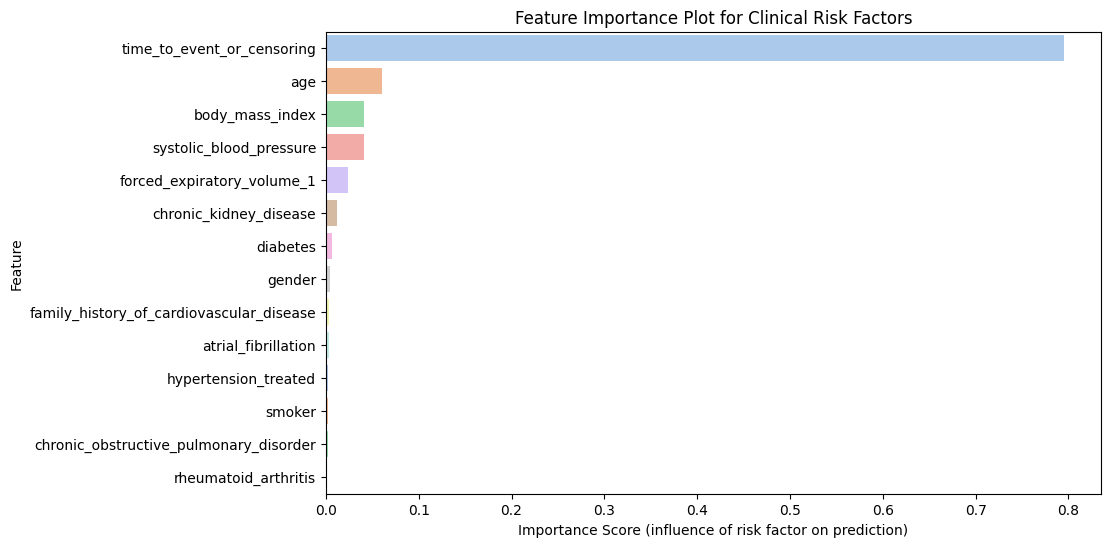

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtaining the feature importances
importance_scores = model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Using matplotlib and seaborn to plot the feature importance graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='pastel')
plt.title('Feature Importance Plot for Clinical Risk Factors')
plt.xlabel('Importance Score (influence of risk factor on prediction)')
plt.ylabel('Feature')
plt.show()

This feature importance plot clearly demonstrated that the most significant feature in the model's success was the 'time to event or censoring' - essentially, the time between data collection and cardiovascular event. If the patient did not have a cardiovascular event, then this feature would be zero, and contain a value only if they did in fact have an event. This clearly displayed that the model's perceived success was in fact simply due to identifying that a patient with a cardiovascular event would rightfully have a non-zero value in this column, and therefore using this as a marker for predicting risk (data leakage). As this obviously had no clinical value, since it is impossible to determine the number of years before someone will have a cardiovascular event without future knowledge, I was forced to remove this column and re-train the model.

In [22]:
X_new = X.drop(columns=['time_to_event_or_censoring'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=1)
model = RandomForestClassifier(random_state=1)
model.fit(X_train, y_train)
rf_predictions = model.predict(X_test)
print(classification_report(y_test, rf_predictions))
print(confusion_matrix(y_test, rf_predictions))
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Random Forest Model ROC-AUC Score: {auc}")

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     18704
           1       0.25      0.05      0.08      1296

    accuracy                           0.93     20000
   macro avg       0.59      0.52      0.52     20000
weighted avg       0.89      0.93      0.91     20000

[[18513   191]
 [ 1234    62]]
Random Forest Model ROC-AUC Score: 0.7746125845201133


This clearly showed a significant drop in the model's output, with a precision of 17% and recall of less than 4%, essentially confirming a failure of the model to succesfully identify patients who had a heart attack or stroke. It should be noted that the accuracy remained high, as 93% of the patients in the testing dataset did not have a cardiovascular event (class imbalance), and therefore an accuracy approaching this could be achieved simply by guessing 'no event' for every patient. This clearly has no clinical value.

An XGBoost model was also trialled to determine if there was a significant improvement in output.

In [23]:
# Importing the pre-built XGBoost model for random forests
from xgboost import XGBClassifier
model = XGBClassifier(random_state=1)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [24]:
xg_predictions = model.predict(X_test)
print(classification_report(y_test, xg_predictions))
print(confusion_matrix(y_test, xg_predictions))
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"XG Boost Model ROC-AUC Score: {auc}")

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     18704
           1       0.34      0.02      0.04      1296

    accuracy                           0.93     20000
   macro avg       0.64      0.51      0.50     20000
weighted avg       0.90      0.93      0.91     20000

[[18651    53]
 [ 1269    27]]
XG Boost Model ROC-AUC Score: 0.8197158922894952


As can be seen above, the performance was essentially unchanged with a basic XGBoost model. An attempt was made to mitigate the impact of class imbalance by introducing cost-sensitive learning. As the number of patients without a heart attack/stroke in the test dataset was approximately 14.3 times larger than that of those with such a event, the scale_pos_weight parameter was changed to reflect this. This essentially signalled to the model that missing a patient who had an event should be penalised 14.3 times more than missing a patient who did not.

In [25]:
model = XGBClassifier(scale_pos_weight=14.3, random_state=1)
model.fit(X_train, y_train)
xg_predictions = model.predict(X_test)
print(classification_report(y_test, xg_predictions))
print(confusion_matrix(y_test, xg_predictions))
print(f"XG Boost Model ROC-AUC Score: {auc}")

              precision    recall  f1-score   support

           0       0.97      0.75      0.84     18704
           1       0.16      0.72      0.27      1296

    accuracy                           0.74     20000
   macro avg       0.57      0.73      0.56     20000
weighted avg       0.92      0.74      0.81     20000

[[13947  4757]
 [  367   929]]
XG Boost Model ROC-AUC Score: 0.8197158922894952


As can be seen above, introducing cost-sensitive learning caused a significant reduction in precision, but was able to improve the recall to around 71%. This means that the model was successful at identifying 71% of people who had a heart attack or stroke, at the expense of identifying many more false positives. This essentially has turned the model into a screening tool - in real-life clinical practice, the benefit gained by individuals of a screening programme from being successfully identified as at risk of an adverse event must outweight the harms from overdiagnosis/overtreatment of false positives. In this particular case, this would depend heavily on the intervention proposed, and would require high quality clinical trial evidence of a successful reduction in morbidity/mortality. For example, if the desired intervention was to check the lipid profile for all those identified at high risk for consideration of starting a statin - before approval as an intervention there would first have to be evidence that there was a significant reduction in cardiovascular events as a result of this change, and secondly the benefit of such reduction would have to be more than the financial/organisational strain placed on the healthcare system from testing a large number of people, approximately 84% of whom would be false positives.

Finally, a repeat feature importance plot was plotted.

/tmp/ipykernel_28258/1926682806.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='pastel')


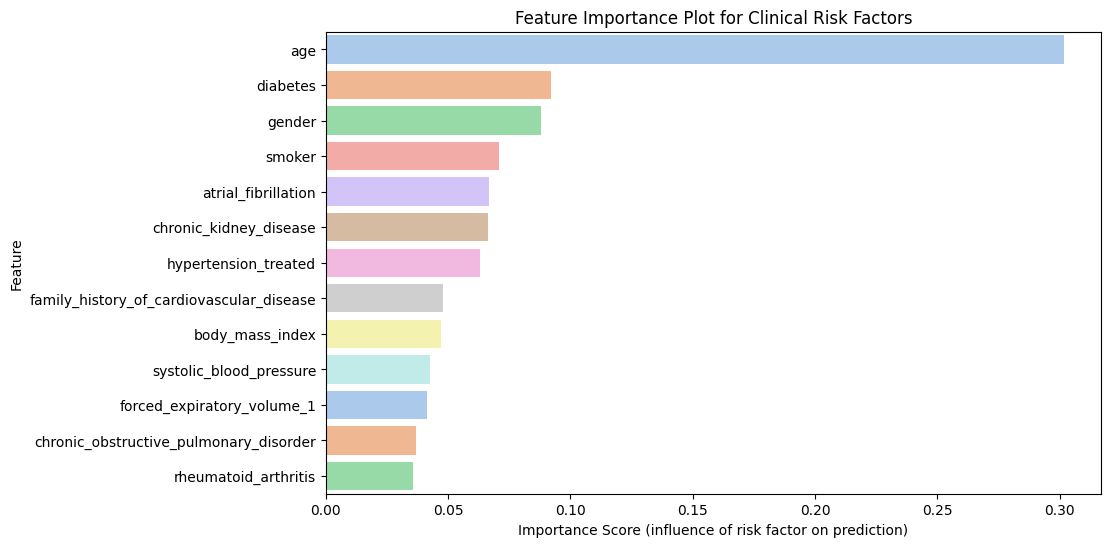

In [26]:
importance_scores = model.feature_importances_
feature_names = X_new.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Using matplotlib and seaborn to plot the feature importance graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='pastel')
plt.title('Feature Importance Plot for Clinical Risk Factors')
plt.xlabel('Importance Score (influence of risk factor on prediction)')
plt.ylabel('Feature')
plt.show()

This plot indicates that age was the most significant risk factor for predicting a cardiovascular event, followed by diabetes, gender and smoking status. More noticeably, the model was much more balanced than the previous in regard to the influence of different factors, with the maximum importance score only being approximately 0.30.

Overall this project taught me about several important issues that can arise when producing a machine learning model for healthcare, namely data cleaning (and possible methods to mitigate this), data leakage, class imbalance and how to attempt to resolve this partially via cost-sensitive learning.